In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install git+https://www.github.com/mouseland/cellpose.git
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile as tiff

from cellpose import models, core, io, plot
from tqdm import trange
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-1i77pr10
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-1i77pr10
  Resolved https://www.github.com/mouseland/cellpose.git to commit 17fb25f40055ec2636aa708dc4cf6625b8b4735d
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 107.8 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.8-py3-none-any.whl size=212051 sha256=1ce45ebdde9db9a93ce795af5e84a32f1a57bd0b59f28df00f68b1b9d41d2c22
  Stored in directory: /tmp/pip-ephem-wheel-cache-lkmpfmc3/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
creating new log file
2025-12-09 20:12:22,708 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/

100%|██████████| 1.15G/1.15G [00:06<00:00, 200MB/s]


# **AJUSTE MANUAL DE HIPERPARÁMETROS**

El objetivo de este Notebook es obtener unos valores iniciales para los parámetros de Cellpose que sean lo más optimos posibles. Dado que la base de datos no cuenta con un conjunto de entrenamiento o algo de referencia, no podemos automatizar este proceso, por lo que se han ejecutado varias instancias de cellpose para un frame en concreto modificando los parámetros de este y se han ordenado de manera matricial para una mejor perspectiva.

Inicialmente cargamos todas las permutaciones posibles de valores paramétricos en un array.

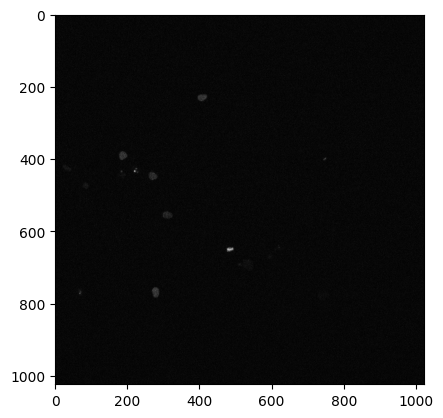

2025-12-09 20:12:53,242 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   0
2025-12-09 20:13:03,123 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   1
2025-12-09 20:13:12,021 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   2
2025-12-09 20:13:20,999 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   3
2025-12-09 20:13:30,026 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   4
2025-12-09 20:13:39,182 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   5
2025-12-09 20:13:48,027 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   6
2025-12-09 20:13:56,779 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   7
2025-12-09 20:14:05,642 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   8
2025-12-09 20:14:14,371 [INFO] processing grayscale image with (1024, 1024) HW
Imagen  0   9
2025-12-09 20:14:22,924 [INFO] processing grayscale image with (1024, 

In [4]:
input_tiff_path = "/content/drive/MyDrive/PID/celldb/MAX230426_bCatTracking_Exp91_20230426_73604_AM_f0000_t0000.tif"
success, frames = cv.imreadmulti(input_tiff_path, [], cv.IMREAD_UNCHANGED)
img = frames[75][:,:,1]

plt.imshow(img, cmap="gray")
plt.show()

flow_thresholds = [0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
cellprob_thresholds = [-5.0,-4.0,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0]
tile_norm_blocksize = 60
a,b = img.shape
imgs = np.zeros(((len(flow_thresholds), len(cellprob_thresholds), a,b)))
for i in range(len(flow_thresholds)):
  for j in range(len(cellprob_thresholds)):
    masks1, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_thresholds[i], cellprob_threshold=cellprob_thresholds[j],
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    imgs[i,j,:,:] = masks1
    print("Imagen ", i, " ", j)

Posteriormente se muestran los resultados de manera matricial.

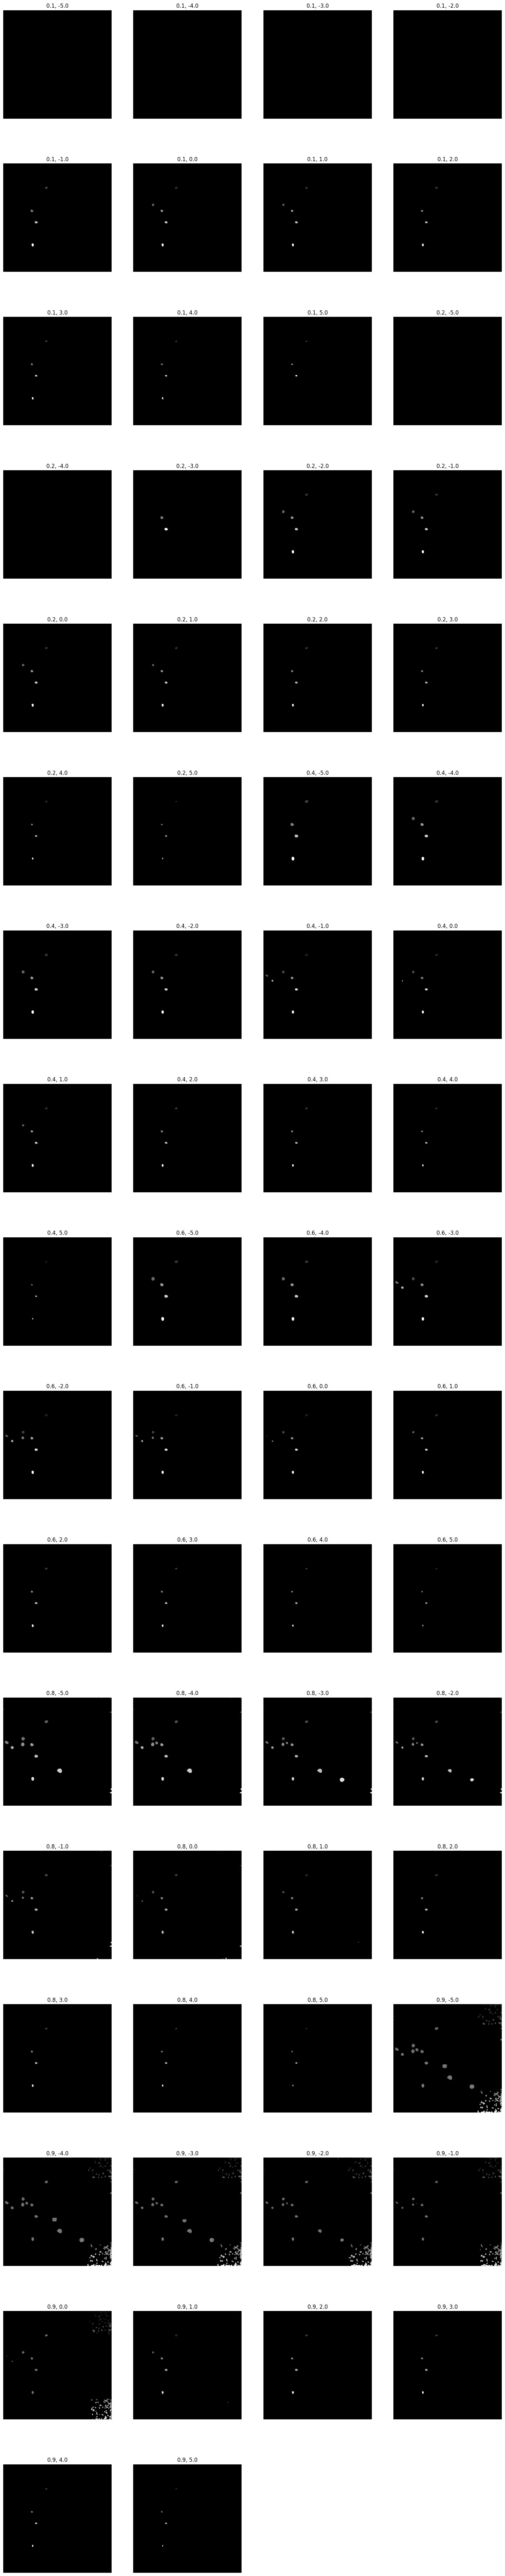

In [6]:
plt.figure(figsize=(20,160))

cont = 1

for i in range(len(flow_thresholds)):
  for j in range(len(cellprob_thresholds)):
    plt.subplot(26,4,cont)
    plt.imshow(imgs[i,j,:,:], cmap = "gray")
    plt.title(f'{flow_thresholds[i]}, {cellprob_thresholds[j]}')
    plt.axis("off")
    cont += 1

Finalmente se han elegido los valores 0.6,-2.